In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer

In [2]:
df = pd.read_csv("Train.csv")

print("Dataset Shape:", df.shape)
display(df.head())
     

Dataset Shape: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [3]:
df.drop(['ID'], axis=1, inplace=True)

print("After Dropping ID:")
display(df.head())

After Dropping ID:


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,D,Flight,4,2,177,3,low,F,44,1233,1
1,F,Flight,4,5,216,2,low,M,59,3088,1
2,A,Flight,2,2,183,4,low,M,48,3374,1
3,B,Flight,3,3,176,4,medium,M,10,1177,1
4,C,Flight,2,2,184,3,medium,F,46,2484,1


In [4]:

max_rating = 5

df['rating_sin'] = np.sin(2 * np.pi * df['Customer_rating'] / max_rating)
df['rating_cos'] = np.cos(2 * np.pi * df['Customer_rating'] / max_rating)

print("Cyclic Encoding Applied:")
display(df[['Customer_rating', 'rating_sin', 'rating_cos']].head())

Cyclic Encoding Applied:


,Customer_rating,rating_sin,rating_cos
0,2,5.877853e-01,-0.809017
1,5,-2.449294e-16,1.000000
2,2,5.877853e-01,-0.809017
3,3,-5.877853e-01,-0.809017
4,2,5.877853e-01,-0.809017


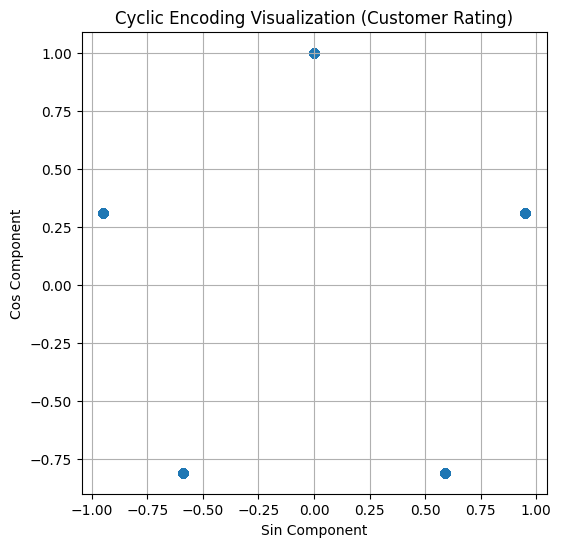

In [5]:
plt.figure(figsize=(6,6))
plt.scatter(df['rating_sin'], df['rating_cos'])
plt.title("Cyclic Encoding Visualization (Customer Rating)")
plt.xlabel("Sin Component")
plt.ylabel("Cos Component")
plt.grid(True)
plt.show()

In [6]:

df.drop('Customer_rating', axis=1, inplace=True)

print("After Dropping Original Rating Column:")
display(df.head())
     

After Dropping Original Rating Column:


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,rating_sin,rating_cos
0,D,Flight,4,177,3,low,F,44,1233,1,5.877853e-01,-0.809017
1,F,Flight,4,216,2,low,M,59,3088,1,-2.449294e-16,1.000000
2,A,Flight,2,183,4,low,M,48,3374,1,5.877853e-01,-0.809017
3,B,Flight,3,176,4,medium,M,10,1177,1,-5.877853e-01,-0.809017
4,C,Flight,2,184,3,medium,F,46,2484,1,5.877853e-01,-0.809017


In [7]:

bin_cols = ['Cost_of_the_Product', 'Weight_in_gms', 'Discount_offered']

print("Before Discretization:")
display(df[bin_cols].head())

Before Discretization:


,Cost_of_the_Product,Weight_in_gms,Discount_offered
0,177,1233,44
1,216,3088,59
2,183,3374,48
3,176,1177,10
4,184,2484,46


In [8]:

kbins = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='uniform')

df[bin_cols] = kbins.fit_transform(df[bin_cols])

print("After Discretization (0–3 bins):")
display(df[bin_cols].head())
     

After Discretization (0–3 bins):


,Cost_of_the_Product,Weight_in_gms,Discount_offered
0,1.0,0.0,2.0
1,2.0,1.0,3.0
2,1.0,1.0,2.0
3,1.0,0.0,0.0
4,1.0,0.0,2.0


In [9]:

print("Final Dataset Shape:", df.shape)
display(df.head())

Final Dataset Shape: (10999, 12)


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,rating_sin,rating_cos
0,D,Flight,4,1.0,3,low,F,2.0,0.0,1,5.877853e-01,-0.809017
1,F,Flight,4,2.0,2,low,M,3.0,1.0,1,-2.449294e-16,1.000000
2,A,Flight,2,1.0,4,low,M,2.0,1.0,1,5.877853e-01,-0.809017
3,B,Flight,3,1.0,4,medium,M,0.0,0.0,1,-5.877853e-01,-0.809017
4,C,Flight,2,1.0,3,medium,F,2.0,0.0,1,5.877853e-01,-0.809017
